In [1]:
# Roll No: 24BAD047
# Name: Jeevanantham K.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv(r'C:\Users\Admin\Desktop\4_sem\ML\EX_NO_7\Mall_Customers.csv')

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Check for missing values
print(df.isnull().sum())

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


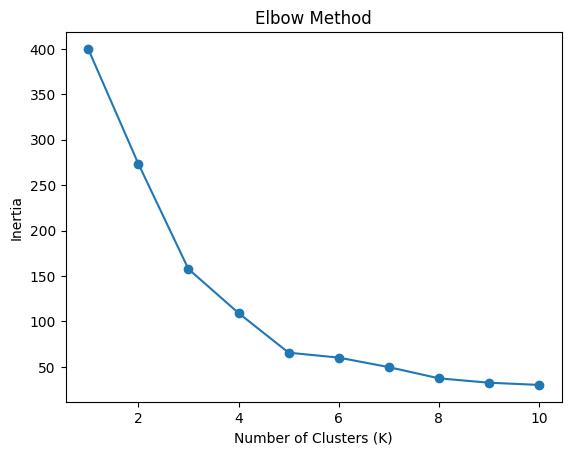

In [4]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['KMeans_Cluster'] = labels_kmeans

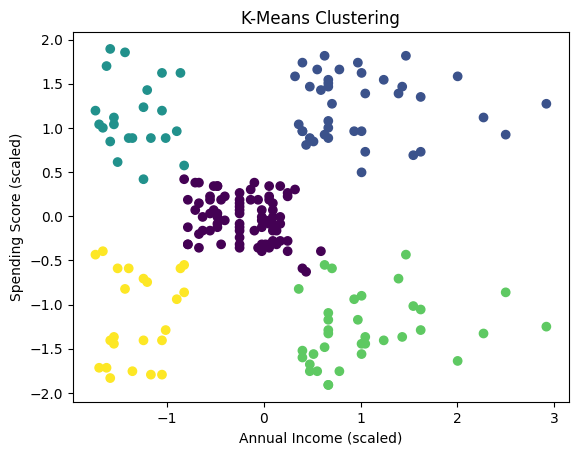

In [6]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

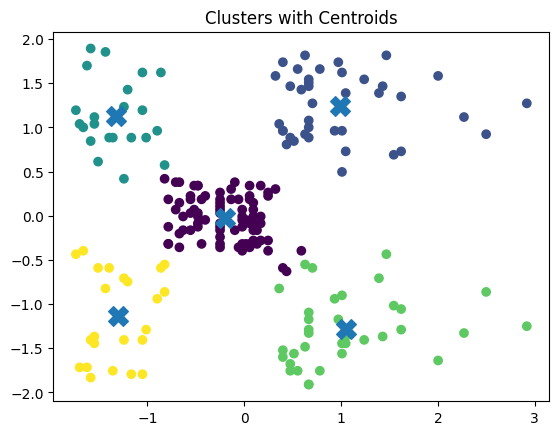

In [7]:
centroids = kmeans.cluster_centers_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title('Clusters with Centroids')
plt.show()

In [8]:
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels_kmeans))

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091
